In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 100


def show_row(titles, imgs, cmaps=None, figsize=(16,4)):
    if cmaps is None:
        cmaps = [None] * len(imgs)
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1:
        axes = [axes]
    for ax, title, img, cmap in zip(axes, titles, imgs, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def safe_imwrite(path, image):
    folder = os.path.dirname(path)
    if folder and not os.path.exists(folder):
        os.makedirs(folder, exist_ok=True)
    success = cv2.imwrite(path, image)
    if not success:
        raise IOError(f'Could not write image to {path}')
    print(f'Saved image to {path}')


def locate_image(*names):
    for name in names:
        candidate = os.path.join('images', name)
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError('None of the candidate image names were found: ' + ', '.join(names))

## 16. Canny edge detection on green_apple.jpg
Run `cv2.Canny()` with threshold pairs `[30, 100]` and `[100, 200]` and compare the results.

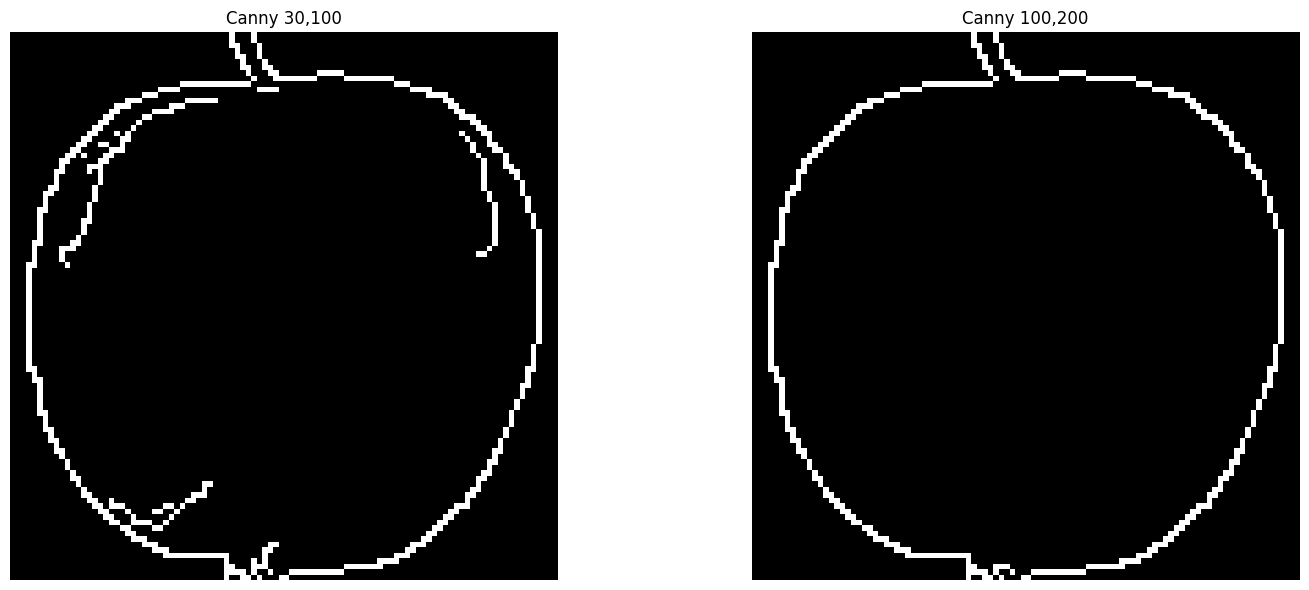

In [2]:
green_apple_path = locate_image('green_apple.jpg')
img_bgr = cv2.imread(green_apple_path)
if img_bgr is None:
    raise FileNotFoundError('green_apple.jpg not found')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

canny_low = cv2.Canny(img_gray, 30, 100)
canny_high = cv2.Canny(img_gray, 100, 200)

show_row(
    ['Canny 30,100', 'Canny 100,200'],
    [canny_low, canny_high],
    ['gray', 'gray'],
    figsize=(16,6)
)

thresholds [30, 100] detect more edges, including some interior texture noise.
Thresholds [100, 200] keep the stronger boundary edges and suppress interior noise, so the fruit outline is cleaner.

Canny pipeline: Gaussian blur removes high-frequency noise, Sobel computes gradients, non-maximum suppression thins edges, and double threshold + hysteresis selects strong continuous edges.

## 17. Extended — Canny from scratch with a custom pipeline
This section implements the full Canny pipeline step-by-step and compares it to `cv2.Canny()`.

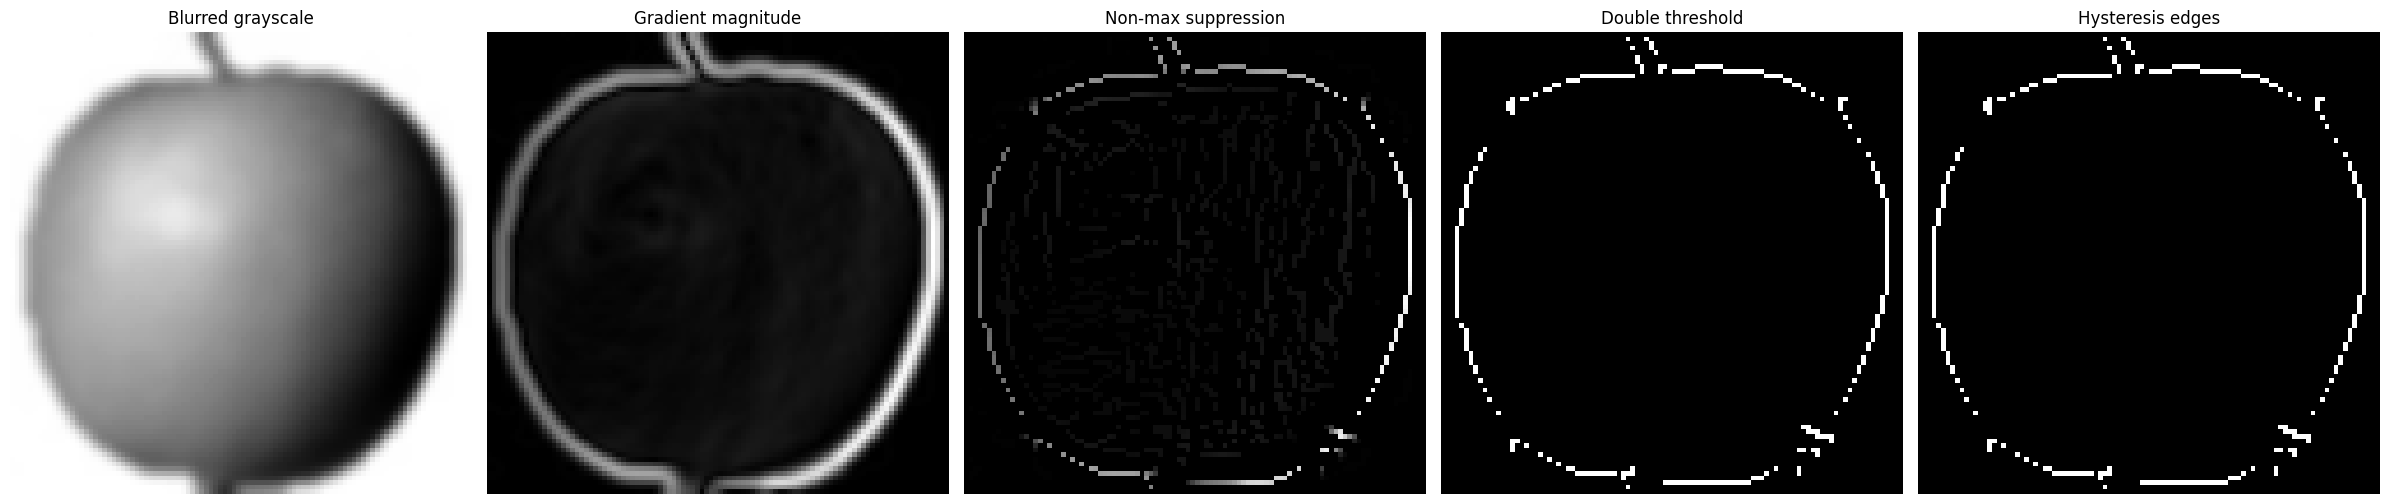

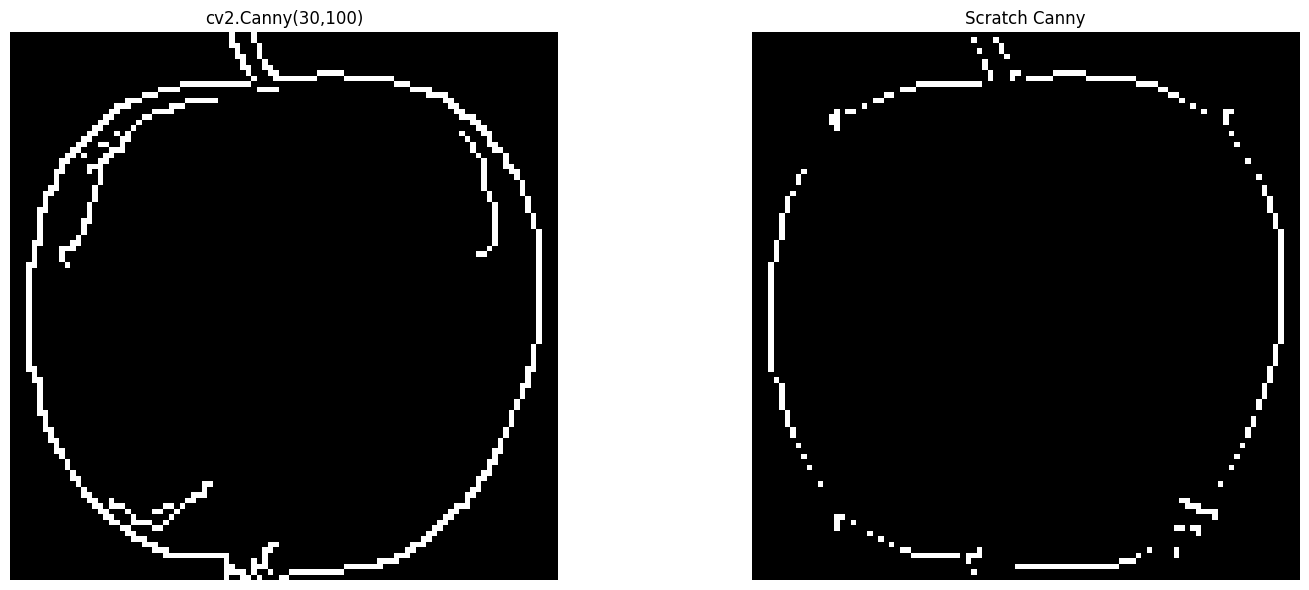

In [3]:
class CannyEdgeDetector:
    def __init__(self, low_threshold=50, high_threshold=150, sigma=1.4):
        self.low_threshold = low_threshold
        self.high_threshold = high_threshold
        self.sigma = sigma

    def gaussian_blur(self, image, ksize=5):
        return cv2.GaussianBlur(image, (ksize, ksize), self.sigma)

    def gradient(self, image):
        gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = np.hypot(gx, gy)
        direction = np.rad2deg(np.arctan2(gy, gx)) % 180
        return magnitude, direction

    def non_maximum_suppression(self, magnitude, direction):
        h, w = magnitude.shape
        result = np.zeros((h, w), dtype=np.float32)

        for y in range(1, h-1):
            for x in range(1, w-1):
                angle = direction[y, x]
                q = 255
                r = 255

                if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                    q = magnitude[y, x+1]
                    r = magnitude[y, x-1]
                elif 22.5 <= angle < 67.5:
                    q = magnitude[y-1, x+1]
                    r = magnitude[y+1, x-1]
                elif 67.5 <= angle < 112.5:
                    q = magnitude[y-1, x]
                    r = magnitude[y+1, x]
                else:
                    q = magnitude[y-1, x-1]
                    r = magnitude[y+1, x+1]

                if magnitude[y, x] >= q and magnitude[y, x] >= r:
                    result[y, x] = magnitude[y, x]
        return result

    def apply_double_threshold(self, image):
        strong = 255
        weak = 75
        strong_i = (image >= self.high_threshold)
        weak_i = ((image >= self.low_threshold) & (image < self.high_threshold))
        result = np.zeros_like(image, dtype=np.uint8)
        result[strong_i] = strong
        result[weak_i] = weak
        return result

    def hysteresis(self, image):
        h, w = image.shape
        for y in range(1, h-1):
            for x in range(1, w-1):
                if image[y, x] == 75:
                    if 255 in image[y-1:y+2, x-1:x+2]:
                        image[y, x] = 255
                    else:
                        image[y, x] = 0
        image[image == 75] = 0
        return image

    def detect(self, image):
        blurred = self.gaussian_blur(image)
        magnitude, direction = self.gradient(blurred)
        nms = self.non_maximum_suppression(magnitude, direction)
        thresh = self.apply_double_threshold(nms)
        edges = self.hysteresis(thresh)
        return edges, blurred, magnitude, direction, nms, thresh


canny_detector = CannyEdgeDetector(low_threshold=30, high_threshold=100)
edges_scratch, blurred, magnitude, direction, nms, thresh = canny_detector.detect(img_gray)

show_row(
    ['Blurred grayscale', 'Gradient magnitude', 'Non-max suppression', 'Double threshold', 'Hysteresis edges'],
    [blurred, np.clip(magnitude / magnitude.max(), 0, 1), np.clip(nms / nms.max(), 0, 1), np.clip(thresh / 255.0, 0, 1), edges_scratch],
    ['gray'] * 5,
    figsize=(24,8)
)

show_row(
    ['cv2.Canny(30,100)', 'Scratch Canny'],
    [canny_low, edges_scratch],
    ['gray', 'gray'],
    figsize=(16,6)
)

Our scratch Canny edge detector follows: blur -> gradient magnitude/direction -> non-maximum suppression -> double threshold -> hysteresis.
The result is comparable to cv2.Canny, though OpenCV may use optimized thresholding/hysteresis and produce slightly different thinning.

## 18. Harris corners on chessboard.png
Use `cv2.cornerHarris()` and dilate the response. Compare thresholds 0.01 and 0.1.

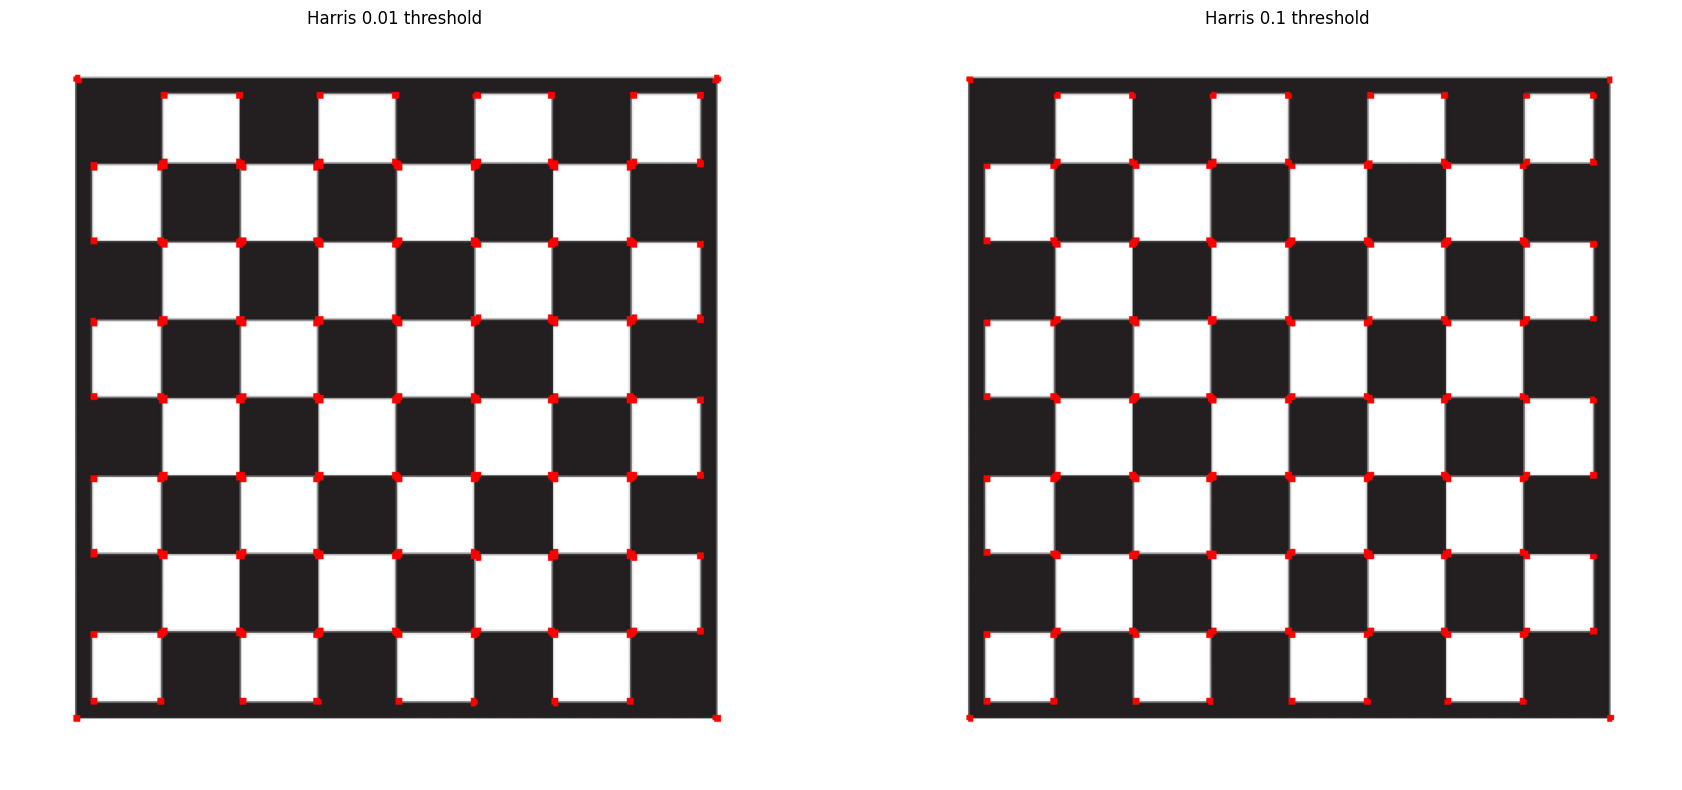

In [4]:
chess_path = locate_image('chessboard.png')
chess_bgr = cv2.imread(chess_path)
if chess_bgr is None:
    raise FileNotFoundError('chessboard.png not found')
chess_gray = cv2.cvtColor(chess_bgr, cv2.COLOR_BGR2GRAY)
chess_gray = np.float32(chess_gray)

harris_response = cv2.cornerHarris(chess_gray, blockSize=2, ksize=3, k=0.04)
harris_response = cv2.dilate(harris_response, None)

result_low = chess_bgr.copy()
result_high = chess_bgr.copy()

threshold_low = 0.01 * harris_response.max()
threshold_high = 0.1 * harris_response.max()
result_low[harris_response > threshold_low] = [0, 0, 255]
result_high[harris_response > threshold_high] = [0, 0, 255]

show_row(
    ['Harris 0.01 threshold', 'Harris 0.1 threshold'],
    [cv2.cvtColor(result_low, cv2.COLOR_BGR2RGB), cv2.cvtColor(result_high, cv2.COLOR_BGR2RGB)],
    [None, None],
    figsize=(18,8)
)

At 0.01, many corners are marked, including weaker responses and some noise.
At 0.1, only the strongest chessboard corners remain, reducing false positives and yielding a cleaner result.

## 19. Hough Circle Transform on mixed fruit bowl
Run `cv2.HoughCircles()` with `minRadius=30` and `maxRadius=100`. Tune `param2` to detect round fruit cleanly.

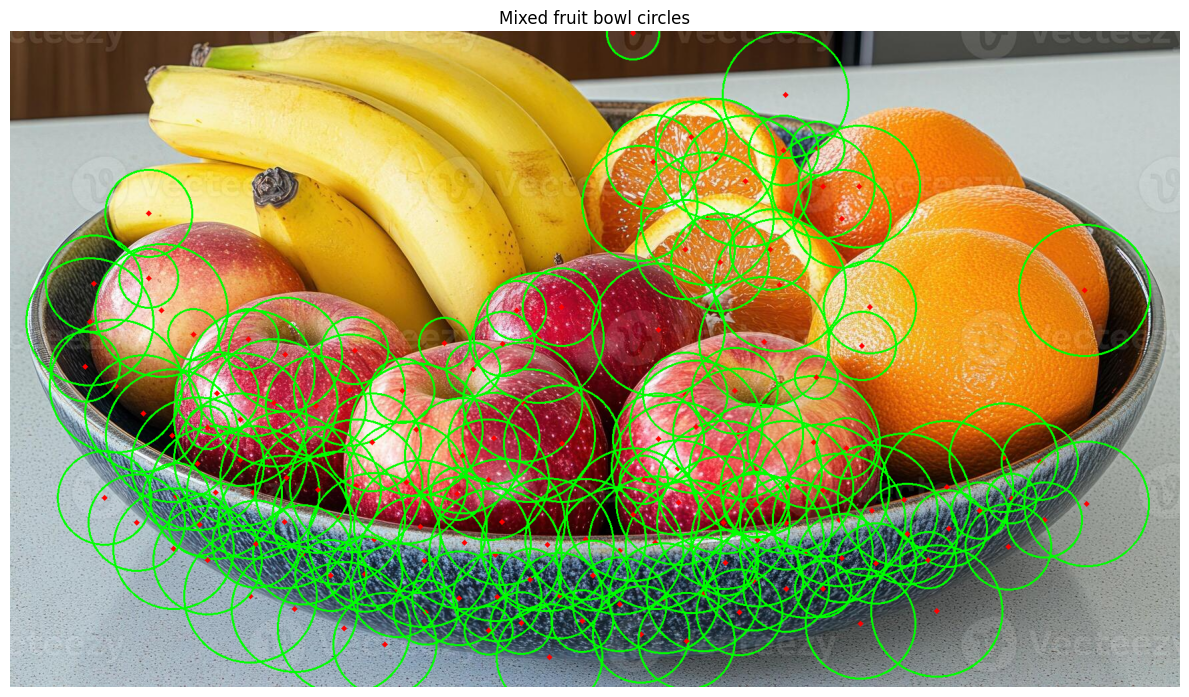

Circles detected: 153


In [5]:
mixed_path = locate_image('mixed_bowl.jpg', 'mixed_fruit_bowl.jpeg', 'mixed_fruit_bowl.jpg')
mixture_bgr = cv2.imread(mixed_path)
if mixture_bgr is None:
    raise FileNotFoundError('mixed_bowl image not found')
mixture_gray = cv2.cvtColor(mixture_bgr, cv2.COLOR_BGR2GRAY)
mixture_gray = cv2.medianBlur(mixture_gray, 5)

circles = cv2.HoughCircles(
    mixture_gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=50,
    param1=100,
    param2=40,
    minRadius=30,
    maxRadius=100
)

output_circles = mixture_bgr.copy()
found = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    found = circles.shape[1]
    for x, y, r in circles[0, :]:
        cv2.circle(output_circles, (x, y), r, (0, 255, 0), 2)
        cv2.circle(output_circles, (x, y), 2, (0, 0, 255), 3)

show_row(
    ['Mixed fruit bowl circles'],
    [cv2.cvtColor(output_circles, cv2.COLOR_BGR2RGB)],
    [None],
    figsize=(12,8)
)

print(f'Circles detected: {found}')

With param2=40, the strongest round fruits are detected. If the count does not match the actual fruit count, the detector is missing occluded or non-circular fruits or producing false detections on bright highlights.


## 20. Full pipeline for one fruit in mixed fruit bowl
Load the bowl, convert to RGB, apply an HSV mask for one fruit type, clean the mask with morphology, detect edges, draw a bounding box, and save the result.

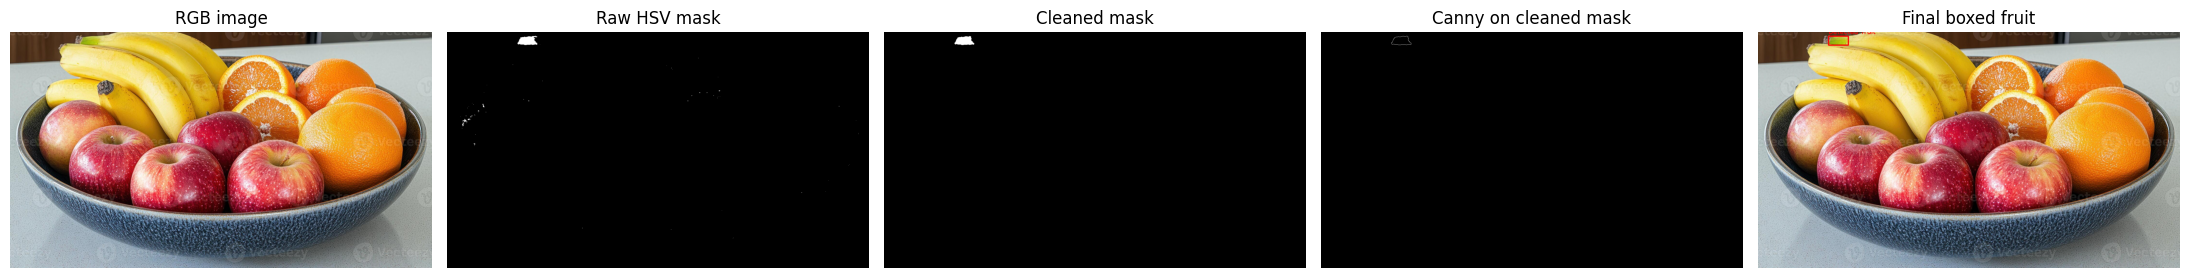

Saved image to images\part_d_final.png


In [6]:
fruit_bgr = cv2.imread(mixed_path)
fruit_rgb = cv2.cvtColor(fruit_bgr, cv2.COLOR_BGR2RGB)
fruit_hsv = cv2.cvtColor(fruit_bgr, cv2.COLOR_BGR2HSV)

# Choose the green apple / lime by selecting green hues in the bowl.
lower_green = np.array([30, 80, 50])
upper_green = np.array([90, 255, 255])
raw_mask = cv2.inRange(fruit_hsv, lower_green, upper_green)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
cleaned_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel)

edges = cv2.Canny(cleaned_mask, 50, 150)

contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    best = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(best)
    boxed = fruit_rgb.copy()
    cv2.rectangle(boxed, (x, y), (x + w, y + h), (255, 0, 0), 3)
    cv2.putText(boxed, 'Detected fruit', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
else:
    boxed = fruit_rgb.copy()
    print('No contour found for the selected fruit mask.')

show_row(
    ['RGB image', 'Raw HSV mask', 'Cleaned mask', 'Canny on cleaned mask', 'Final boxed fruit'],
    [fruit_rgb, raw_mask, cleaned_mask, edges, boxed],
    [None, 'gray', 'gray', 'gray', None],
    figsize=(22,10)
)

save_path = os.path.join('images', 'part_d_final.png')
safe_imwrite(save_path, cv2.cvtColor(boxed, cv2.COLOR_RGB2BGR))